# Week 2 — Fluid Mechanics Review & the Material Derivative

**OE 754 / 854 — Ocean Waves & Tides**

This week sets up *all* the machinery we'll use for the rest of the semester: the material derivative, conservation of mass, and the Eulerian vs. Lagrangian distinction. This notebook is light on derivations (those are in the lecture notes) and heavy on visualizations. The concepts that trip people up (like Eulerian $\partial u/\partial t$ vs. Lagrangian $Du/Dt$) are much easier to see than to read about.

### Goals

1. Visualize the Eulerian vs. Lagrangian split with a synthetic converging-channel flow.
2. Compute $Du/Dt = \partial u/\partial t + (\mathbf u \cdot \nabla)u$ directly from a simple analytical flow and check it against the finite-difference Lagrangian rate.
3. Do a dimensional-consistency check on the flux, momentum, and Bernoulli equations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import figure_style as fs

g = 9.81

## 1. Eulerian vs. Lagrangian: a converging channel

Consider the steady 2D flow $u(x) = U_0 (1 + x/L)$ in a channel that narrows linearly, so the velocity accelerates from $U_0$ at $x = 0$ to $2U_0$ at $x = L$. (Continuity plus steady plus incompressible gives this from a constant volumetric flux and a linear width taper.)

A fixed current meter at any point $x_0$ sees a **constant** velocity: $\partial u/\partial t = 0$. No time variation, the flow is steady. But a drifter released at $x = 0$ *accelerates* as it moves downstream into faster water.

Both statements are true. They measure different things.


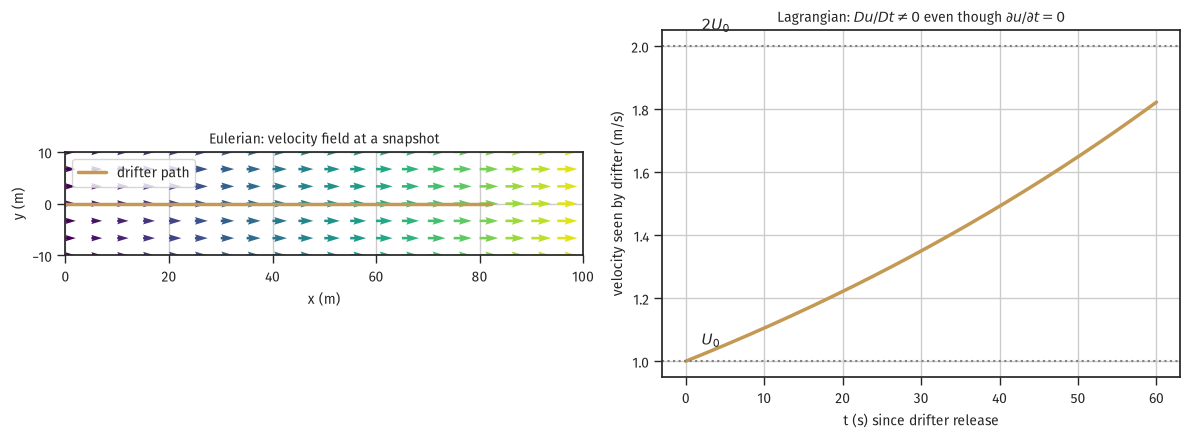

In [2]:
U0 = 1.0    # m/s at channel inlet
L = 100.0   # m, length of taper

def u_steady(x):
    return U0 * (1 + x / L)

# Eulerian picture: velocity field at a snapshot in time
x_field = np.linspace(0, L, 21)
y_field = np.linspace(-10, 10, 7)
X, Y = np.meshgrid(x_field, y_field)
U = u_steady(X)
V = np.zeros_like(U)

# Lagrangian picture: track a parcel released at x=0, y=0
# dx/dt = u(x), x(0) = 0. Analytical: x(t) = L*(exp(U0 t / L) - 1)
t_track = np.linspace(0, 60, 200)
x_track = L * (np.exp(U0 * t_track / L) - 1)
u_track = u_steady(x_track)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Eulerian field
ax1.quiver(X, Y, U, V, U, cmap='viridis', scale=50)
ax1.plot(x_track[x_track < L], np.zeros_like(x_track[x_track < L]),
         '-', color=fs.color_list[3], lw=2.5, label='drifter path')
ax1.set_xlim(0, L)
ax1.set_ylim(-10, 10)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_title('Eulerian: velocity field at a snapshot')
ax1.set_aspect('equal')
ax1.legend(loc='upper left')

# Right: Lagrangian velocity along the drifter path
ax2.plot(t_track, u_track, lw=2.5, color=fs.color_list[3])
ax2.set_xlabel('t (s) since drifter release')
ax2.set_ylabel('velocity seen by drifter (m/s)')
ax2.set_title('Lagrangian: $Du/Dt \\neq 0$ even though $\\partial u/\\partial t = 0$')
ax2.axhline(U0, ls=':', color='0.5', lw=1.5)
ax2.axhline(2*U0, ls=':', color='0.5', lw=1.5)
ax2.text(2, U0 + 0.05, r'$U_0$', fontsize=11)
ax2.text(2, 2*U0 + 0.05, r'$2U_0$', fontsize=11)

plt.tight_layout()
plt.show()

Despite $\partial u/\partial t = 0$ at every fixed point, a parcel following the flow sees its velocity *double* over about a minute. That acceleration is the **advective** piece of the material derivative:

$$\frac{Du}{Dt} = \underbrace{\frac{\partial u}{\partial t}}_{\text{Eulerian rate}} + \underbrace{(\mathbf u \cdot \nabla) u}_{\text{advective}} = 0 + u\frac{du}{dx} = U_0(1 + x/L) \cdot \frac{U_0}{L}.$$

## 2. Verifying $Du/Dt$ numerically

Compute the advective term analytically, and compare to the finite-difference rate measured along the drifter trajectory. The two should agree to the $O(\Delta t^2)$ truncation error of the centered difference, which for this time step is parts per million, not percent.


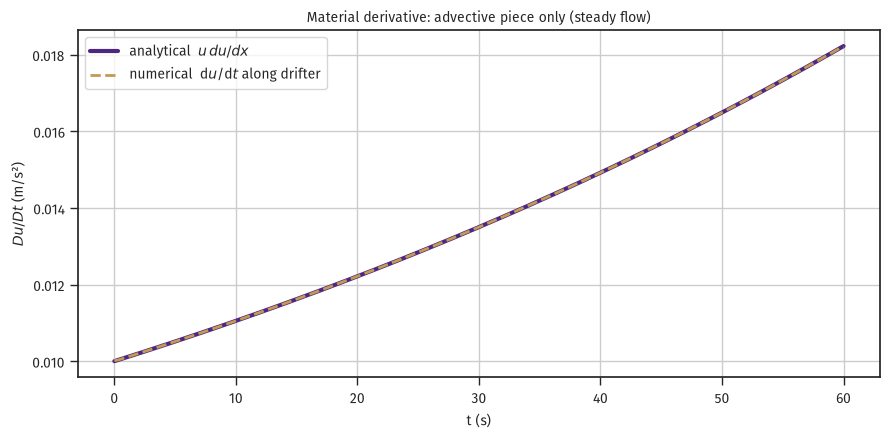

Time step dt = 0.3015 s
Max relative error in interior: 1.515e-06
Expected (dt/tau)²/6          : 1.515e-06


In [3]:
# Analytical: Du/Dt = u * du/dx = U0^2/L * (1 + x/L)
DuDt_analytic = U0**2 / L * (1 + x_track / L)

# Numerical: difference the drifter's velocity record
DuDt_numeric = np.gradient(u_track, t_track)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_track, DuDt_analytic, lw=3, color=fs.color_list[0], label='analytical  $u\\,du/dx$')
ax.plot(t_track, DuDt_numeric,  '--', lw=2, color=fs.color_list[3],
        label='numerical  d$u$/d$t$ along drifter')
ax.set_xlabel('t (s)')
ax.set_ylabel(r'$Du/Dt$ (m/s²)')
ax.set_title(r'Material derivative: advective piece only (steady flow)')
ax.legend()
plt.tight_layout()
plt.show()

# Relative agreement (excluding endpoints where np.gradient is sided)
interior = slice(5, -5)
rel_err = np.abs(DuDt_analytic[interior] - DuDt_numeric[interior]).max() / DuDt_analytic[interior].max()
dt = t_track[1] - t_track[0]
# Centered-difference truncation for u ~ exp(t/tau), tau = L/U0: (dt/tau)^2 / 6
print(f'Time step dt = {dt:.4f} s')
print(f'Max relative error in interior: {rel_err:.3e}')
print(f'Expected (dt/tau)²/6          : {(dt*U0/L)**2/6:.3e}')


The two lines lie on top of each other, as expected: there's nothing subtle here beyond the chain rule, and the residual disagreement is just the centered-difference truncation error, which lands right on the predicted $(\Delta t/\tau)^2/6 \sim 10^{-6}$.

## 3. Incompressibility as a flow property

The lecture notes make a point of this: **"incompressible" is a statement about the flow, not the fluid.** Water is slightly compressible (acoustic waves propagate through it), but in surface-wave flows, $\nabla \cdot \mathbf u \approx 0$ is an excellent approximation because the characteristic wave speeds are negligible compared to the speed of sound.

Verify this on the converging-channel flow. In 2D with $u(x)$ only, continuity forces the channel width to taper. If we instead pretend the width is constant, $\partial u/\partial x \ne 0$ implies $\nabla \cdot \mathbf u \ne 0$, a violation we can quantify.


In [4]:
# In 2D, continuity says du/dx + dv/dy = 0.
# For u(x) = U0 (1 + x/L), continuity requires dv/dy = -U0/L everywhere.
# If the channel width W(x) tapers, v(x, y) = -(U0/L) * y works and
# the top/bottom boundaries satisfy the no-flux condition.

# Neglecting v entirely leaves div u = du/dx = U0/L.
# The fractional compression rate: (1/rho) d rho/dt = -div u = -U0/L
# Timescale: L/U0 = 100 s. Relative density change scales as the squared
# Mach number M = U/c_s with c_s = 1500 m/s in water.

U = 1.0  # m/s typical flow speed
c_s = 1500.0  # m/s acoustic speed in water
M = U / c_s
print(f'Mach number for a 1 m/s ocean flow:  M = {M:.2e}')
print(f'Compressibility correction scales as M² = {M**2:.2e}')
print(f'i.e., density variations are ~ {M**2*1e6:.2f} parts per million. Incompressible is fine.')


Mach number for a 1 m/s ocean flow:  M = 6.67e-04
Compressibility correction scales as M² = 4.44e-07
i.e., density variations are ~ 0.44 parts per million. Incompressible is fine.


## 4. Dimensional consistency check

Every equation in this course has to be dimensionally consistent. Most algebra errors you'll make break dimensional consistency. Habit starts now. Let's verify a few of the equations we'll meet:

- **Continuity**: $\nabla \cdot \mathbf u = 0$. LHS units: (m/s) / m = 1/s. Zero has no units, so the equation reads "rate [1/s] = 0", which is fine.

- **Navier–Stokes momentum** (one term): $\rho\,Du/Dt = -\partial p/\partial x$. LHS: (kg/m³)(m/s²) = kg/(m²·s²) = Pa/m. RHS: (Pa)/m. ✓

- **Unsteady Bernoulli**: $-\partial\phi/\partial t + \tfrac12 |\mathbf u|^2 + P/\rho + gz = C(t)$. Each term is m²/s². Check a few:


In [5]:
# String-based unit check on the Bernoulli terms.
import numpy as np

def units_check(name, expr_value, expected_dim_str):
    print(f'  {name:<40s}  numerical value: {expr_value:<12.3g}  expected: {expected_dim_str}')

# Representative scales for a moderate ocean wave: H = 2m, T = 10s, h = 50m
H, T, h = 2.0, 10.0, 50.0
omega = 2*np.pi/T
k = omega**2 / g   # deep-water approx
a = H/2
rho = 1025.0

# phi has units of m^2/s; eta has units of m; u has units of m/s
phi_scale = g*a/omega                # gH/(2 omega)
u_scale = omega * a                  # particle velocity amplitude
eta_scale = a

# Bernoulli terms at the surface:
term_dphidt = phi_scale * omega                # [m^2/s * 1/s] = m^2/s^2
term_kinetic = 0.5 * u_scale**2                # [m^2/s^2]
term_gravity = g * eta_scale                   # [m/s^2 * m] = m^2/s^2
# Pressure term: P/rho. For an Airy wave, P_dyn ~ rho g eta, so P/rho ~ g eta:
term_pressure = g * eta_scale                  # [m^2/s^2]

print('Bernoulli-equation terms (units of m^2/s^2 for an H=2m, T=10s wave):\n')
units_check('∂φ/∂t',                  term_dphidt,  '~ 10  (m/s)^2')
units_check('½ |u|²',                 term_kinetic, '~ 1   (m/s)^2')
units_check('P / ρ  (dynamic)',       term_pressure,'~ 10  (m/s)^2')
units_check('g η  (at surface)',      term_gravity, '~ 10  (m/s)^2')

print()
print(f'ka = {k*a:.4f};   ½|u|² / gη = {term_kinetic/term_gravity:.4f}  (= ½ka = {0.5*k*a:.4f})')
print('The kinetic term is smaller than the linear terms by O(ka), not O((ka)^2),')
print('which is exactly why we drop it when linearizing next week.')


Bernoulli-equation terms (units of m^2/s^2 for an H=2m, T=10s wave):

  ∂φ/∂t                                     numerical value: 9.81          expected: ~ 10  (m/s)^2
  ½ |u|²                                    numerical value: 0.197         expected: ~ 1   (m/s)^2
  P / ρ  (dynamic)                          numerical value: 9.81          expected: ~ 10  (m/s)^2
  g η  (at surface)                         numerical value: 9.81          expected: ~ 10  (m/s)^2

ka = 0.0402;   ½|u|² / gη = 0.0201  (= ½ka = 0.0201)
The kinetic term is smaller than the linear terms by O(ka), not O((ka)^2),
which is exactly why we drop it when linearizing next week.


## 5. Bernoulli along a streamline: the converging nozzle

Steady, inviscid, irrotational flow along a horizontal streamline obeys

$$P + \tfrac12\rho u^2 = \text{const},$$

so where continuity speeds the flow up, the pressure must drop. For a nozzle whose area contracts by a factor $c$: $u_2 = c\,u_1$ and $P_2 = P_1 + \tfrac12\rho\,(u_1^2 - u_2^2)$. The cell below verifies the pressure-velocity trade along the same converging channel from Section 1, the working pattern for PS1's Bernoulli problem.

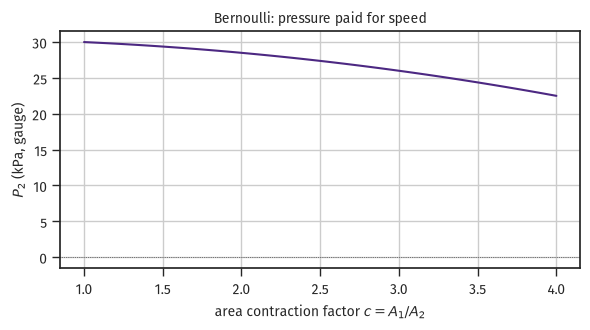

contraction x4: u2 = 4.0 m/s, P2 = 22.5 kPa gauge
Energy check: P + rho u^2/2 constant to machine precision by construction;
the physics content is the sign: faster flow, lower pressure.


In [6]:
# Bernoulli check along the Section-1 converging channel
rho_w = 1000.0
u1, P1 = 1.0, 30e3          # upstream speed (m/s), gauge pressure (Pa)
contraction = np.linspace(1, 4, 100)

u2 = contraction * u1
P2 = P1 + 0.5 * rho_w * (u1**2 - u2**2)

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.plot(contraction, P2 / 1e3)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('area contraction factor $c = A_1/A_2$')
ax.set_ylabel('$P_2$ (kPa, gauge)')
ax.set_title('Bernoulli: pressure paid for speed')
fig.tight_layout()
plt.show()

c = 4
print(f'contraction x{c}: u2 = {c*u1:.1f} m/s, '
      f'P2 = {(P1 + 0.5*rho_w*(u1**2 - (c*u1)**2))/1e3:.1f} kPa gauge')
print('Energy check: P + rho u^2/2 constant to machine precision by construction;')
print('the physics content is the sign: faster flow, lower pressure.')

The numerical comparison drives home the scaling argument in next week's lecture: for a moderate wave, the kinetic term $\tfrac12|\mathbf u|^2$ is smaller than $g\eta$ by a factor $\tfrac12 ka$. Here $ka \approx 0.040$, so the ratio is about $0.020$. *Two percent.* That's the justification for linearization: not a hand-wave, an actual small number. (Note the order: the neglected term is $O(ka)$ relative to the ones we keep, not $O((ka)^2)$. Two percent is small, but it is the same two percent that Stokes theory in Week 9 puts back.)

## 6. Exercise

Take a 2D unsteady flow like $u(x, t) = U_0 + a \sin(kx - \omega t)$ (a sinusoid riding on a mean current). Compute $Du/Dt$ analytically. Which of the three pieces (unsteady, mean advection, wave self-advection) dominate in the small-amplitude limit $a \ll U_0$? In the pure-wave limit $U_0 = 0$?

## Looking ahead

Week 3 closes the fluid review with Bernoulli and sets up the water-wave boundary-value problem. By the end of that lecture you'll have four equations (Laplace, BBC, KFSBC, DFSBC) that the whole rest of the course builds on.
